# Atelier 3 (après-midi) : évaluer, détecter, regrouper, industrialiser

Notebook de référence du formateur, noyau **Python (venv-ml)**. À exécuter après `atelier3_matin.ipynb` (il utilise `prevision_conso.py`).

# PARTIE 4 : ÉVALUER PROPREMENT

Reprise de l'après-midi : notebook `atelier3_apresmidi`, noyau **Python (venv-ml)**. Si les variables du matin sont encore en mémoire, la Cellule 23 les recalcule simplement à partir du module.

## Cellule 23 : Reprendre proprement avec le module

- **`prevision_conso`** : le module créé ce matin (Cellule 21).
- **`preparer()`** : rejoue chargement, nettoyage et variables.
- **Objectif** : partir d'un état **identique** pour tous, quel que soit le noyau.

In [1]:
# === CELLULE 23 : Reprise ===
import numpy as np
import pandas as pd
import prevision_conso as pc

d = pc.preparer()
train, test = pc.decouper(d)
print(len(d), "lignes |", len(train), "entraînement |", len(test), "test")
print(pc.COLONNES)

4320 lignes | 2099 entraînement | 799 test
['site_id', 'heure', 'weekend', 'capacity_mw', 'lag_24', 'lag_168', 'moy_veille']


## Cellule 24 : Piège 1 : la fuite de données

- **Fuite** : une variable contient, directement ou non, la **réponse** à prédire.
- **Exemple** : une moyenne glissante qui **inclut** l'heure courante (oubli du décalage).
- **Test** : le score « s'améliore » ; en production, cette variable n'existe pas encore.

In [2]:
# === CELLULE 24 : Fuite de données ===
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

d_f = d.assign(moy_fuite=d.groupby("site_id")["conso_mw"].transform(lambda s: s.rolling(2, min_periods=1).mean()))
tr_f, te_f = pc.decouper(d_f)

for nom, cols in (("sans fuite", pc.VARIABLES), ("avec fuite", pc.VARIABLES + ["moy_fuite"])):
    m = HistGradientBoostingRegressor(random_state=0).fit(tr_f[cols], tr_f["conso_mw"])
    print(f"{nom:<11} MAE test : {mean_absolute_error(te_f['conso_mw'], m.predict(te_f[cols])):.4f} MW")

sans fuite  MAE test : 0.0590 MW


avec fuite  MAE test : 0.0394 MW


## Cellule 25 : Piège 2 : mélanger le temps

- **Simulation** : une hausse de **3 % par jour** est ajoutée à une **copie** des données (jeu réel inchangé).
- **Variable `jour_num`** : le numéro du jour, tentante pour « suivre la tendance ».
- **Deux découpages** : aléatoire (`train_test_split`) contre temporel.

In [3]:
# === CELLULE 25 : Découpage aléatoire ou temporel ===
from sklearn.model_selection import train_test_split

jours = (d["timestamp"] - d["timestamp"].min()).dt.days
tendance = d.assign(conso_mw=d["conso_mw"] * (1 + 0.03 * jours), jour_num=jours).dropna(subset=["conso_mw"])
cols = ["heure", "weekend", "capacity_mw", "jour_num"]

a, b = train_test_split(tendance, test_size=0.25, random_state=0)
passe, futur = tendance[tendance["timestamp"] < pc.COUPURE], tendance[tendance["timestamp"] >= pc.COUPURE]

for nom, (ent, val) in {"aléatoire": (a, b), "temporel": (passe, futur)}.items():
    m = HistGradientBoostingRegressor(random_state=0).fit(ent[cols], ent["conso_mw"])
    print(f"{nom:<10} MAE : {mean_absolute_error(val['conso_mw'], m.predict(val[cols])):.3f} MW")
print("Niveau moyen :", round(tendance["conso_mw"].mean(), 2), "MW")

aléatoire  MAE : 0.076 MW


temporel   MAE : 0.151 MW
Niveau moyen : 1.43 MW


## Cellule 26 : Validation croisée pour séries temporelles

- **Un seul découpage** : le résultat dépend de la semaine choisie.
- **`TimeSeriesSplit`** : plusieurs plis, toujours **passé → futur**.
- **`cross_val_score`** : entraîne et évalue sur chaque pli (`neg_` : scikit-learn maximise, donc l'erreur est négative).

In [4]:
# === CELLULE 26 : TimeSeriesSplit ===
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

ordre = train.sort_values(["timestamp", "site_id"]).reset_index(drop=True)
tscv = TimeSeriesSplit(n_splits=4)
for i, (ent, val) in enumerate(tscv.split(ordre), 1):
    print(f"pli {i} : entraînement {ordre.loc[ent[0], 'timestamp']:%d/%m} -> {ordre.loc[ent[-1], 'timestamp']:%d/%m} | validation {ordre.loc[val[0], 'timestamp']:%d/%m} -> {ordre.loc[val[-1], 'timestamp']:%d/%m}")

scores = cross_val_score(HistGradientBoostingRegressor(random_state=0), ordre[pc.VARIABLES], ordre["conso_mw"],
                         cv=tscv, scoring="neg_mean_absolute_error")
print("MAE par pli :", (-scores).round(3), "| moyenne :", round(-scores.mean(), 3))

pli 1 : entraînement 08/01 -> 11/01 | validation 11/01 -> 14/01
pli 2 : entraînement 08/01 -> 14/01 | validation 14/01 -> 17/01
pli 3 : entraînement 08/01 -> 17/01 | validation 17/01 -> 20/01
pli 4 : entraînement 08/01 -> 20/01 | validation 20/01 -> 23/01


MAE par pli : [0.148 0.078 0.073 0.065] | moyenne : 0.091


## Cellule 27 : Piège 3 : entraîner avec les pics aberrants

- **Rappel** : 15 mesures dépassent la capacité ; on les avait retirées (Cellule 5).
- **Test** : les **réintroduire** dans l'entraînement, puis évaluer sur le même test propre.
- **Trois modèles** : le linéaire, la forêt et le gradient boosting réagissent différemment.

In [5]:
# === CELLULE 27 : Effet des pics sur l'entraînement ===
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

avec = d[(d["timestamp"] >= pc.DEBUT_UTILE) & (d["timestamp"] < pc.COUPURE) & d["conso_brute"].notna()].assign(conso_mw=lambda x: x["conso_brute"])
print(int(avec["pic"].sum()), "pics dans l'entraînement")
med = train[pc.VARIABLES].median()

modeles = {"linéaire": LinearRegression(),
           "forêt": RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1),
           "gradient boosting": HistGradientBoostingRegressor(random_state=0)}
lignes = {}
for nom, m in modeles.items():
    ligne = {}
    for etiquette, jeu in (("sans pics", train), ("avec pics", avec)):
        m.fit(jeu[pc.VARIABLES].fillna(med), jeu["conso_mw"])
        ligne[etiquette] = mean_absolute_error(test["conso_mw"], m.predict(test[pc.VARIABLES].fillna(med)))
    lignes[nom] = ligne
print(pd.DataFrame(lignes).T.round(3))

10 pics dans l'entraînement


                   sans pics  avec pics
linéaire               0.103      0.107
forêt                  0.055      0.062
gradient boosting      0.058      0.070


## Cellule 28 : Régler les hyperparamètres : `GridSearchCV`

- **Hyperparamètres** : réglages choisis **avant** l'apprentissage (profondeur, vitesse, nombre d'arbres).
- **`GridSearchCV`** : essaie toutes les combinaisons (3 × 3 × 2 = 18), chacune validée sur les 4 plis temporels.
- **Le test reste intact** : il ne sert qu'**une fois**, à la fin.

In [6]:
# === CELLULE 28 : GridSearchCV ===
from sklearn.model_selection import GridSearchCV

grille = {"max_depth": [3, 6, None], "learning_rate": [0.05, 0.1, 0.3], "max_iter": [100, 300]}
gs = GridSearchCV(HistGradientBoostingRegressor(random_state=0), grille, cv=tscv,
                  scoring="neg_mean_absolute_error", n_jobs=-1)
gs.fit(ordre[pc.VARIABLES], ordre["conso_mw"])

print("Meilleurs réglages :", gs.best_params_)
print("MAE validation croisée :", round(-gs.best_score_, 4))
defaut = HistGradientBoostingRegressor(random_state=0).fit(train[pc.VARIABLES], train["conso_mw"])
print("MAE test, réglages par défaut :", round(mean_absolute_error(test["conso_mw"], defaut.predict(test[pc.VARIABLES])), 4))
print("MAE test, meilleurs réglages  :", round(mean_absolute_error(test["conso_mw"], gs.predict(test[pc.VARIABLES])), 4))
res = pd.DataFrame(gs.cv_results_).sort_values("rank_test_score").head(3)
print(res[["param_max_depth", "param_learning_rate", "param_max_iter", "mean_test_score"]].round(3).to_string(index=False))

Meilleurs réglages : {'learning_rate': 0.3, 'max_depth': 6, 'max_iter': 100}
MAE validation croisée : 0.0825


MAE test, réglages par défaut : 0.059
MAE test, meilleurs réglages  : 0.0583
param_max_depth  param_learning_rate  param_max_iter  mean_test_score
              6                  0.3             100           -0.082
              3                  0.3             100           -0.083
           None                  0.3             100           -0.083


## Cellule 29 : Quelles variables comptent ? `permutation_importance`

- **Principe** : mélanger **une** colonne du test ; plus l'erreur augmente, plus la variable comptait.
- **Sur le test** : mesure ce qui sert **réellement** à prévoir, pas ce que le modèle a mémorisé.
- **`n_repeats`** : répète le mélange pour stabiliser le résultat.

lag_168        0.531
lag_24         0.151
site_id        0.084
weekend        0.010
moy_veille     0.009
capacity_mw    0.001
heure         -0.000


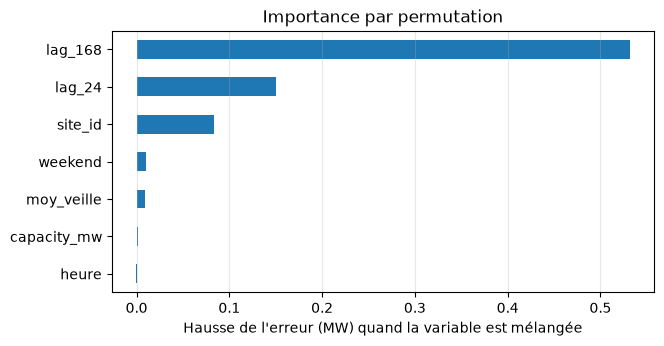

In [7]:
# === CELLULE 29 : Importance des variables ===
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.inspection import permutation_importance

final = pc.construire_modele().fit(train[pc.COLONNES], train["conso_mw"])
r = permutation_importance(final, test[pc.COLONNES], test["conso_mw"], n_repeats=10, random_state=0,
                           scoring="neg_mean_absolute_error", n_jobs=-1)
importance = pd.Series(r.importances_mean, index=pc.COLONNES).sort_values()
print(importance.sort_values(ascending=False).round(3).to_string())

Path("out").mkdir(exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 3.4))
importance.plot.barh(ax=ax, color="#1f77b4")
ax.set_xlabel("Hausse de l'erreur (MW) quand la variable est mélangée")
ax.set_title("Importance par permutation")
ax.grid(alpha=0.3, axis="x")
fig.savefig("out/fig_importance.png", dpi=110, bbox_inches="tight")

## Cellule 30 : Réel contre prévu, et erreur par heure

- **Nuage réel/prévu** : les points doivent suivre la diagonale.
- **Erreur par heure** : révèle les moments où le modèle est moins précis.
- **Sur le test** uniquement.

Heure la plus difficile : 18 h | MAE 0.083
Heure la plus facile    : 3 h | MAE 0.036


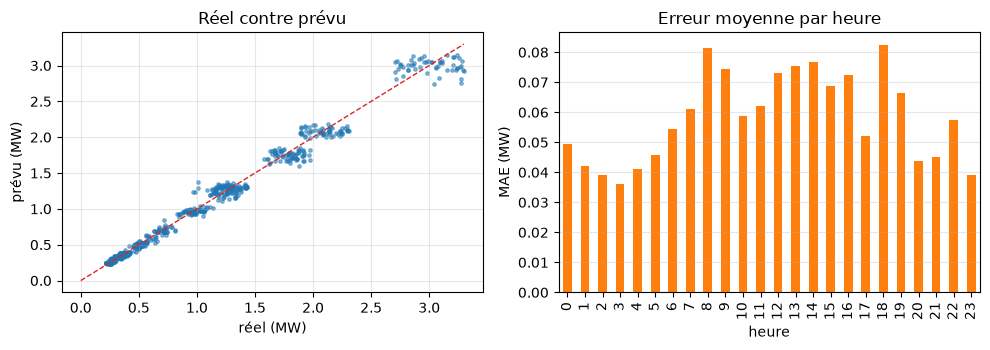

In [8]:
# === CELLULE 30 : Diagnostic graphique ===
t = test.assign(prevu=final.predict(test[pc.COLONNES]))
t["erreur"] = (t["conso_mw"] - t["prevu"]).abs()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.6))
a1.scatter(t["conso_mw"], t["prevu"], s=6, alpha=0.5, color="#1f77b4")
a1.plot([0, t["conso_mw"].max()], [0, t["conso_mw"].max()], color="#d62728", linestyle="--", linewidth=1)
a1.set_xlabel("réel (MW)"); a1.set_ylabel("prévu (MW)"); a1.set_title("Réel contre prévu"); a1.grid(alpha=0.3)
t.groupby("heure")["erreur"].mean().plot.bar(ax=a2, color="#ff7f0e")
a2.set_xlabel("heure"); a2.set_ylabel("MAE (MW)"); a2.set_title("Erreur moyenne par heure"); a2.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig("out/fig_diagnostic.png", dpi=110, bbox_inches="tight")

par_heure = t.groupby("heure")["erreur"].mean()
print("Heure la plus difficile :", int(par_heure.idxmax()), "h | MAE", round(par_heure.max(), 3))
print("Heure la plus facile    :", int(par_heure.idxmin()), "h | MAE", round(par_heure.min(), 3))

## Cellule 31 : Une prévision avec marge : régression quantile

- **Besoin métier** : une **fourchette**, pas seulement une valeur.
- **`loss="quantile"`** : le modèle apprend le 10e ou le 90e centile.
- **Couverture** : part des mesures réelles **dans** la fourchette ; visée : 80 %. À **toujours vérifier** sur le test.

In [9]:
# === CELLULE 31 : Fourchette de prévision ===
def fourchette(**reglages):
    bas = HistGradientBoostingRegressor(loss="quantile", quantile=0.1, random_state=0, **reglages).fit(train[pc.VARIABLES], train["conso_mw"])
    haut = HistGradientBoostingRegressor(loss="quantile", quantile=0.9, random_state=0, **reglages).fit(train[pc.VARIABLES], train["conso_mw"])
    return bas.predict(test[pc.VARIABLES]), haut.predict(test[pc.VARIABLES])

for nom, reglages in (("réglages par défaut", {}), ("plus prudent (feuilles ≥ 40)", {"max_depth": 3, "min_samples_leaf": 40})):
    q10, q90 = fourchette(**reglages)
    dans = (test["conso_mw"] >= q10) & (test["conso_mw"] <= q90)
    print(f"{nom:<30} couverture {dans.mean():.1%} (visé 80 %) | largeur moyenne {(q90 - q10).mean():.3f} MW")

réglages par défaut            couverture 65.6% (visé 80 %) | largeur moyenne 0.171 MW


plus prudent (feuilles ≥ 40)   couverture 77.2% (visé 80 %) | largeur moyenne 0.201 MW


# PARTIE 5 : DÉTECTER LES ANOMALIES

## Cellule 32 : La règle métier : taux de charge supérieur à 1

- **Vérité connue** : le générateur a injecté **15 pics** ; on peut donc mesurer ce que trouve chaque méthode (dans la réalité, il n'y a pas d'étiquette).
- **Règle** : mesure ÷ capacité > 1, sans apprentissage.
- **Bilan** : vrais positifs (VP), faux positifs (FP), faux négatifs (FN), **précision** et **rappel**.

In [10]:
# === CELLULE 32 : Règle de taux de charge ===
a = d[d["conso_brute"].notna()].copy()
a["taux_brut"] = a["conso_brute"] / a["capacity_mw"]
vrais = a["pic"]

def bilan(predits):
    vp = int((vrais & predits).sum())
    fp = int((~vrais & predits).sum())
    fn = int((vrais & ~predits).sum())
    return {"VP": vp, "FP": fp, "FN": fn,
            "précision": round(vp / max(vp + fp, 1), 2), "rappel": round(vp / max(vp + fn, 1), 2)}

print(len(a), "mesures valides,", int(vrais.sum()), "pics")
print("Règle taux > 1 :", bilan(a["taux_brut"] > 1))

3970 mesures valides, 15 pics
Règle taux > 1 : {'VP': 15, 'FP': 0, 'FN': 0, 'précision': 1.0, 'rappel': 1.0}


## Cellule 33 : `IsolationForest` sur la consommation brute

- **`IsolationForest`** : isole les points **rares** en coupant les données au hasard ; plus un point s'isole vite, plus il est anormal.
- **`contamination`** : proportion d'anomalies attendue (ici 15 sur le total).
- **`predict`** : renvoie **-1** pour une anomalie, **1** pour un point normal.

In [11]:
# === CELLULE 33 : IsolationForest, consommation brute ===
from sklearn.ensemble import IsolationForest

taux_anomalie = vrais.mean()
iso = IsolationForest(contamination=taux_anomalie, random_state=0).fit(a[["conso_brute"]])
predits = iso.predict(a[["conso_brute"]]) == -1
print("Consommation brute :", bilan(predits))
print(a.loc[predits, ["site_id", "conso_brute", "pic"]].sort_values("conso_brute").head(6).to_string(index=False))

Consommation brute : {'VP': 7, 'FP': 7, 'FN': 8, 'précision': 0.5, 'rappel': 0.47}
     site_id  conso_brute   pic
SITE_IND_001        3.288 False
SITE_IND_001        3.294 False
SITE_IND_001        3.294 False
SITE_IND_001        3.296 False
SITE_IND_001        3.298 False
SITE_IND_001        3.300 False


## Cellule 34 : La même méthode sur le taux de charge

- **Changement d'échelle** : mesure ÷ capacité rend les six sites **comparables**.
- **`contamination="auto"`** : le modèle décide seul du seuil ; comparer avec le réglage précédent.
- **Même algorithme**, autres variables : seule l'entrée change.

In [12]:
# === CELLULE 34 : IsolationForest, taux de charge ===
iso_t = IsolationForest(contamination=taux_anomalie, random_state=0).fit(a[["taux_brut"]])
predits_t = iso_t.predict(a[["taux_brut"]]) == -1
print("Taux de charge, contamination fixée :", bilan(predits_t))

auto = IsolationForest(contamination="auto", random_state=0).fit(a[["taux_brut"]])
predits_auto = auto.predict(a[["taux_brut"]]) == -1
print("Taux de charge, contamination auto  :", bilan(predits_auto), "|", int(predits_auto.sum()), "alertes")

Taux de charge, contamination fixée : {'VP': 15, 'FP': 0, 'FN': 0, 'précision': 1.0, 'rappel': 1.0}


Taux de charge, contamination auto  : {'VP': 15, 'FP': 1003, 'FN': 0, 'précision': 0.01, 'rappel': 1.0} | 1018 alertes


## Cellule 35 : Deux algorithmes, trois jeux de variables

- **`LocalOutlierFactor`** : compare la densité autour d'un point à celle de ses voisins ; testé avec **20** puis **50** voisins.
- **Trois jeux** : consommation brute, taux de charge, taux de charge + heure.
- **Même `contamination`** pour tous : la comparaison est équitable.

In [13]:
# === CELLULE 35 : Comparatif ===
from sklearn.neighbors import LocalOutlierFactor

jeux = {"conso brute": ["conso_brute"], "taux": ["taux_brut"], "taux + heure": ["taux_brut", "heure"]}
lignes = []
for nom_jeu, cols in jeux.items():
    for nom_algo, algo in (("IsolationForest", IsolationForest(contamination=taux_anomalie, random_state=0)),
                           ("LOF, 20 voisins", LocalOutlierFactor(n_neighbors=20, contamination=taux_anomalie)),
                           ("LOF, 50 voisins", LocalOutlierFactor(n_neighbors=50, contamination=taux_anomalie))):
        p = algo.fit_predict(a[cols]) == -1
        lignes.append({"variables": nom_jeu, "algorithme": nom_algo, **bilan(p)})
print(pd.DataFrame(lignes).to_string(index=False))

   variables      algorithme  VP  FP  FN  précision  rappel
 conso brute IsolationForest   7   7   8       0.50    0.47
 conso brute LOF, 20 voisins   8   7   7       0.53    0.53
 conso brute LOF, 50 voisins   8   6   7       0.57    0.53
        taux IsolationForest  15   0   0       1.00    1.00
        taux LOF, 20 voisins   0  14  15       0.00    0.00
        taux LOF, 50 voisins  15   0   0       1.00    1.00
taux + heure IsolationForest  15   0   0       1.00    1.00
taux + heure LOF, 20 voisins  15   0   0       1.00    1.00
taux + heure LOF, 50 voisins  15   0   0       1.00    1.00


## Cellule 36 : Classer plutôt que trancher : les scores d'anomalie

- **`score_samples`** : plus la valeur est **basse**, plus le point est anormal.
- **Classement** : on examine les *N* plus suspects, sans fixer de seuil.
- **Précision@15** : parmi les 15 premiers, combien sont de vrais pics ?

In [14]:
# === CELLULE 36 : Scores d'anomalie ===
a["score"] = iso_t.score_samples(a[["taux_brut"]])
classement = a.sort_values("score")
print(classement[["site_id", "taux_brut", "score", "pic"]].head(3).round(3).to_string(index=False))
print("Précision@15 :", round(classement["pic"].head(15).mean(), 2))
print("Écart entre le 15e et le 16e score :", round(classement["score"].iloc[15] - classement["score"].iloc[14], 3))
print("Écart moyen entre deux scores voisins :", round(classement["score"].diff().abs().mean(), 5))

     site_id  taux_brut  score  pic
SITE_COM_001      1.796 -0.839 True
SITE_COM_001      1.708 -0.838 True
SITE_IND_002      1.667 -0.836 True
Précision@15 : 1.0
Écart entre le 15e et le 16e score : 0.071
Écart moyen entre deux scores voisins : 0.00011


## Cellule 37 : Anomalies par le modèle de prévision : les résidus

- **Résidu** : mesure − prévision. Un résidu énorme = valeur inattendue **compte tenu du contexte** (heure, jour, site).
- **Modèle** : le pipeline de la Partie 3, entraîné **sans** les pics.
- **Avantage** : détecte aussi des écarts **dans** les limites de capacité (absents ici).

In [15]:
# === CELLULE 37 : Résidus du modèle ===
b = d[(d["timestamp"] >= pc.DEBUT_UTILE) & d["conso_brute"].notna()].copy()
b["prevu"] = final.predict(b[pc.COLONNES])
b["residu"] = b["conso_brute"] - b["prevu"]
b["z"] = (b["residu"] - b["residu"].median()) / b["residu"].std()

haut = b.reindex(b["residu"].abs().sort_values(ascending=False).index).head(15)
print("Parmi les 15 plus gros résidus :", int(haut["pic"].sum()), "pics")
print(haut[["site_id", "timestamp", "conso_brute", "prevu"]].head(3).assign(prevu=lambda x: x["prevu"].round(2)).to_string(index=False))
print("Résidu médian des mesures normales :", round(b.loc[~b["pic"], "residu"].abs().median(), 3), "MW")

Parmi les 15 plus gros résidus : 13 pics
     site_id           timestamp  conso_brute  prevu
SITE_IND_002 2025-01-26 02:00:00        5.835   0.71
SITE_IND_002 2025-01-23 03:00:00        5.655   1.25
SITE_IND_002 2025-01-15 17:00:00        5.846   2.10
Résidu médian des mesures normales : 0.027 MW


## Cellule 38 : Piège : chercher des anomalies dans des données non nettoyées

- **Données brutes** : les codes `-999`, `-888`, `-777` sont encore là, pris pour de vraies mesures.
- **Le modèle** fait ce qu'on lui demande : il isole ce qui est **rare**.
- **Question** : trouve-t-il les pics… ou les codes capteur ?

In [16]:
# === CELLULE 38 : Données non nettoyées ===
ref = pd.read_csv("data/sites_reference.csv", encoding="utf-8-sig")[["site_id", "capacity_mw"]]
brut = pd.read_csv("data/consommation_30jours.csv", encoding="utf-8-sig").rename(columns={"consumption_mw": "conso_mw"})
sale = brut.drop_duplicates().merge(ref, on="site_id").dropna(subset=["conso_mw"])
sale = sale.assign(taux=sale["conso_mw"] / sale["capacity_mw"])

iso_s = IsolationForest(contamination=15 / len(sale), random_state=0).fit(sale[["taux"]])
alertes = sale[iso_s.predict(sale[["taux"]]) == -1]
print(len(alertes), "alertes | valeurs de conso_mw signalées :", alertes["conso_mw"].value_counts().to_dict())
print("Pics réellement trouvés :", int((alertes["taux"] > 1).sum()))

11 alertes | valeurs de conso_mw signalées : {-999.0: 11}
Pics réellement trouvés : 0


## Cellule 39 : Voir les anomalies détectées

- **Un panneau par site** : taux de charge dans le temps.
- **Rouge** : anomalies retenues par `IsolationForest` sur le taux de charge.
- **Ligne pointillée** : la capacité (taux = 1).

15 alertes affichées


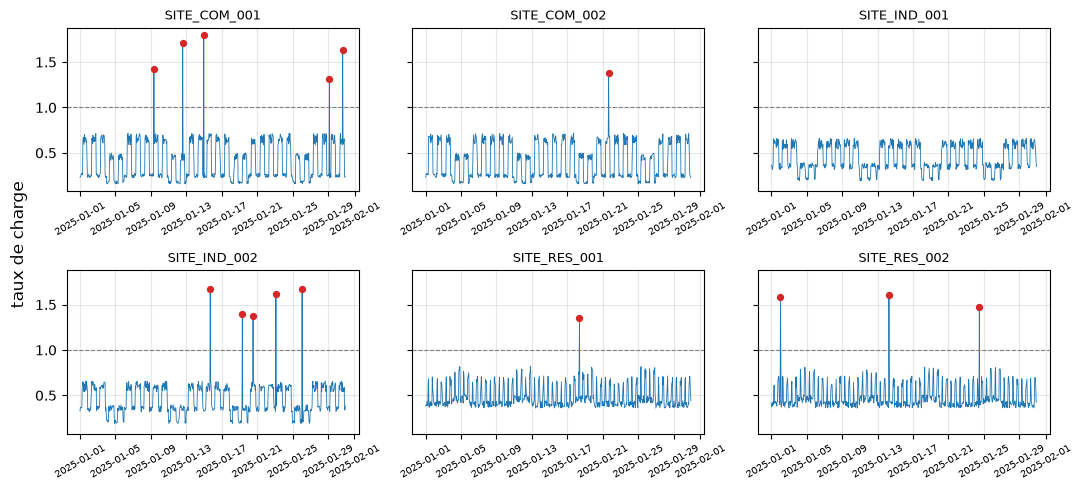

In [17]:
# === CELLULE 39 : Figure anomalies ===
import matplotlib.pyplot as plt
from pathlib import Path

Path("out").mkdir(exist_ok=True)
a["alerte"] = predits_t
fig, axes = plt.subplots(2, 3, figsize=(11, 5), sharey=True)
for ax, (site, g) in zip(axes.ravel(), a.groupby("site_id")):
    ax.plot(g["timestamp"], g["taux_brut"], color="#1f77b4", linewidth=0.6)
    ax.scatter(g.loc[g["alerte"], "timestamp"], g.loc[g["alerte"], "taux_brut"], color="#d62728", s=18, zorder=3)
    ax.axhline(1, color="#7f7f7f", linestyle="--", linewidth=0.8)
    ax.set_title(site, fontsize=9); ax.grid(alpha=0.3)
    ax.tick_params(axis="x", labelsize=7, rotation=30)
fig.supylabel("taux de charge")
fig.tight_layout()
fig.savefig("out/fig_anomalies.png", dpi=110, bbox_inches="tight")
print(int(a["alerte"].sum()), "alertes affichées")

# PARTIE 6 : REGROUPER ET CLASSER

## Cellule 40 : Un profil par site et par jour

- **180 profils** : 6 sites × 30 jours, chacun de 24 valeurs (une par heure).
- **Manquants** : comblés par interpolation **dans chaque site** (choix technique, à valider avec le métier).
- **Division par la moyenne du jour** : on compare la **forme** de la courbe, pas la taille du site.

In [18]:
# === CELLULE 40 : Profils journaliers ===
comble = d.assign(conso_i=d.groupby("site_id")["conso_mw"].transform(lambda s: s.interpolate(limit_direction="both")),
                  jour=d["timestamp"].dt.normalize())
absolus = comble.pivot_table(index=["site_id", "jour"], columns="heure", values="conso_i")
formes = absolus.div(absolus.mean(axis=1), axis=0)

print(formes.shape, "| valeurs manquantes :", int(formes.isna().sum().sum()))
print(formes.iloc[:2, [0, 6, 12, 18]].round(2))
types = d.drop_duplicates("site_id").set_index("site_id")["site_type"]
type_jour = formes.index.get_level_values("site_id").map(types).to_numpy(dtype=object)
print(pd.Series(type_jour).value_counts().to_dict())

(180, 24) | valeurs manquantes : 0
heure                      0     6     12    18
site_id      jour                              
SITE_COM_001 2025-01-01  0.52  0.60  1.60  1.43
             2025-01-02  0.57  0.58  1.48  1.54
{'Commercial': 60, 'Industrie': 60, 'Residentiel': 60}


## Cellule 41 : Combien de groupes ? Inertie et silhouette

- **`KMeans(k)`** : regroupe les profils en *k* familles, **sans étiquette**.
- **Inertie** : distance totale aux centres ; baisse toujours quand *k* augmente ; on cherche le **coude**.
- **Silhouette** : de -1 à 1, plus elle est haute, mieux les groupes sont séparés.

In [19]:
# === CELLULE 41 : Choisir k ===
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(formes)
    print(f"k = {k} | inertie {km.inertia_:7.2f} | silhouette {silhouette_score(formes, km.labels_):.3f}")

k = 2 | inertie   77.16 | silhouette 0.581
k = 3 | inertie   21.06 | silhouette 0.676
k = 4 | inertie   19.50 | silhouette 0.568
k = 5 | inertie   18.91 | silhouette 0.485


k = 6 | inertie   17.88 | silhouette 0.350


## Cellule 42 : Les familles trouvées, comparées aux types connus

- **k = 3** : choisi à la cellule précédente.
- **`crosstab`** : croise les groupes trouvés avec le vrai type de site (que l'algorithme **ignore**).
- **`adjusted_rand_score`** : 1 = regroupement identique à la réalité, 0 = hasard.

In [20]:
# === CELLULE 42 : KMeans, k = 3 ===
from sklearn.metrics import adjusted_rand_score

km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(formes)
print(pd.crosstab(pd.Series(type_jour, name="type de site"), pd.Series(km.labels_, name="groupe")))
print("Indice de Rand ajusté :", round(adjusted_rand_score(type_jour, km.labels_), 3))

groupe         0   1   2
type de site            
Commercial     0   0  60
Industrie     60   0   0
Residentiel    0  60   0
Indice de Rand ajusté : 1.0


## Cellule 43 : Le profil moyen de chaque groupe

- **`cluster_centers_`** : la courbe moyenne de chaque groupe.
- **Nom des groupes** : c'est **l'humain** qui les nomme, en regardant les courbes.
- **Lecture** : heures de pointe et de creux.

[1.19 1.42 1.47] pointe de chaque groupe


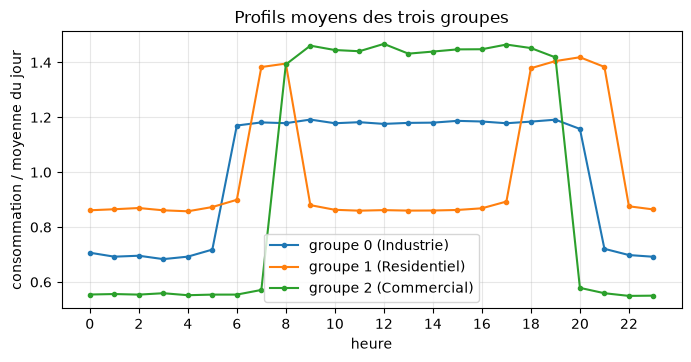

In [21]:
# === CELLULE 43 : Figure des groupes ===
import matplotlib.pyplot as plt
from pathlib import Path

Path("out").mkdir(exist_ok=True)
fig, ax = plt.subplots(figsize=(8, 3.6))
for i, centre in enumerate(km.cluster_centers_):
    type_majoritaire = pd.Series(type_jour[km.labels_ == i]).mode()[0]
    ax.plot(range(24), centre, marker="o", markersize=3, label=f"groupe {i} ({type_majoritaire})")
ax.set_xlabel("heure"); ax.set_ylabel("consommation / moyenne du jour")
ax.set_title("Profils moyens des trois groupes")
ax.set_xticks(range(0, 24, 2)); ax.legend(); ax.grid(alpha=0.3)
fig.savefig("out/fig_groupes.png", dpi=110, bbox_inches="tight")
print(np.round(km.cluster_centers_.max(axis=1), 2), "pointe de chaque groupe")

## Cellule 44 : Pourquoi mettre à l'échelle : `StandardScaler`

- **Distance** : `KMeans` additionne des écarts ; une variable en **kW** (des centaines) écrase une variable de **rapport** (0 à 4).
- **Trois variables par site et par jour** : consommation moyenne (kW), rapport nuit/jour, contraste max/min.
- **`StandardScaler`** : centre chaque colonne (moyenne 0) et la réduit (écart-type 1) ; toutes pèsent alors autant.

In [22]:
# === CELLULE 44 : Mise à l'échelle ===
from sklearn.preprocessing import StandardScaler

resume = pd.DataFrame({
    "moyenne_kw": absolus.mean(axis=1) * 1000,
    "ratio_nuit_jour": absolus.loc[:, 0:5].mean(axis=1) / absolus.loc[:, 8:17].mean(axis=1),
    "contraste": absolus.max(axis=1) / absolus.min(axis=1),
})
print(resume.describe().loc[["mean", "std"]].round(2))

sans = KMeans(n_clusters=3, n_init=10, random_state=0).fit(resume)
avec = KMeans(n_clusters=3, n_init=10, random_state=0).fit(StandardScaler().fit_transform(resume))
print("Rand ajusté sans mise à l'échelle :", round(adjusted_rand_score(type_jour, sans.labels_), 3))
print("Rand ajusté avec mise à l'échelle :", round(adjusted_rand_score(type_jour, avec.labels_), 3))

      moyenne_kw  ratio_nuit_jour  contraste
mean      994.02             0.64       2.33
std       744.18             0.23       0.53
Rand ajusté sans mise à l'échelle : 0.322
Rand ajusté avec mise à l'échelle : 1.0


## Cellule 45 : Classer le type de site : validation par site

- **Classification** : prédire une **catégorie** (Industrie, Commercial, Résidentiel) et non un nombre.
- **`LeaveOneGroupOut`** : chaque site est testé **sans avoir été vu** ; les 30 jours d'un même site ne sont jamais séparés.
- **Pourquoi** : un tirage aléatoire mettrait des jours du même site dans les deux camps (fuite).

In [23]:
# === CELLULE 45 : Classification du type de site ===
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict

sites = formes.index.get_level_values("site_id").to_numpy(dtype=object)
clf = RandomForestClassifier(n_estimators=200, random_state=0)
predit = cross_val_predict(clf, formes, type_jour, groups=sites, cv=LeaveOneGroupOut())

noms = ["Industrie", "Commercial", "Residentiel"]
print("Précision globale :", accuracy_score(type_jour, predit))
print(pd.DataFrame(confusion_matrix(type_jour, predit, labels=noms), index=noms, columns=noms))

Précision globale : 1.0
             Industrie  Commercial  Residentiel
Industrie           60           0            0
Commercial           0          60            0
Residentiel          0           0           60


## Cellule 46 : Classes déséquilibrées : reconnaître un jour de week-end

- **Objectif** : dire si un profil journalier est celui d'un **week-end**, avec la charge relative au niveau habituel du site.
- **Déséquilibre** : environ 1 jour sur 4 seulement.
- **Piège** : un modèle qui répond toujours « semaine » a déjà **environ 70 %** de bonnes réponses.

In [24]:
# === CELLULE 46 : Jour de week-end ===
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score

niveau = comble.groupby("site_id")["conso_i"].transform("mean")
relatif = comble.assign(rel=comble["conso_i"] / niveau).pivot_table(index=["site_id", "jour"], columns="heure", values="rel")
jour = relatif.index.get_level_values("jour")
y = (jour.dayofweek >= 5).astype(int)
passe, futur = jour < pc.COUPURE, jour >= pc.COUPURE
print("Week-ends : entraînement", int(y[passe].sum()), "/", int(passe.sum()), "| test", int(y[futur].sum()), "/", int(futur.sum()))

candidats = {"toujours « semaine »": DummyClassifier(strategy="most_frequent"),
             "régression logistique": LogisticRegression(max_iter=1000),
             "forêt": RandomForestClassifier(n_estimators=200, random_state=0)}
lignes = {}
for nom, m in candidats.items():
    m.fit(relatif[passe], y[passe])
    p = m.predict(relatif[futur])
    lignes[nom] = {"exactitude": accuracy_score(y[futur], p),
                   "précision": precision_score(y[futur], p, zero_division=0),
                   "rappel": recall_score(y[futur], p), "F1": f1_score(y[futur], p)}
print(pd.DataFrame(lignes).T.round(2))

Week-ends : entraînement 36 / 138 | test 12 / 42


                       exactitude  précision  rappel   F1
toujours « semaine »         0.71        0.0    0.00  0.0
régression logistique        0.90        1.0    0.67  0.8
forêt                        1.00        1.0    1.00  1.0


## Cellule 47 : Régler le seuil : précision contre rappel

- **`predict_proba`** : probabilité d'être un week-end ; `predict` coupe à **0,5**.
- **Abaisser le seuil** : détecte plus de week-ends (rappel ↑) au risque de fausses alertes (précision ↓).
- **`class_weight="balanced"`** : donne plus de poids à la classe rare pendant l'apprentissage.

In [25]:
# === CELLULE 47 : Seuil de décision ===
logit = LogisticRegression(max_iter=1000).fit(relatif[passe], y[passe])
proba = logit.predict_proba(relatif[futur])[:, 1]
for seuil in (0.5, 0.3, 0.2, 0.1):
    p = (proba >= seuil).astype(int)
    print(f"seuil {seuil:.1f} | précision {precision_score(y[futur], p, zero_division=0):.2f} | rappel {recall_score(y[futur], p):.2f}")

equilibre = LogisticRegression(max_iter=1000, class_weight="balanced").fit(relatif[passe], y[passe])
p = equilibre.predict(relatif[futur])
print(f"class_weight balanced | précision {precision_score(y[futur], p, zero_division=0):.2f} | rappel {recall_score(y[futur], p):.2f}")

seuil 0.5 | précision 1.00 | rappel 0.67
seuil 0.3 | précision 0.47 | rappel 0.67
seuil 0.2 | précision 0.44 | rappel 0.67
seuil 0.1 | précision 0.50 | rappel 1.00
class_weight balanced | précision 0.44 | rappel 0.67


# PARTIE 7 : INDUSTRIALISER ET PASSER VERS FABRIC

### Préparer un second environnement, `.venv-ml-ancien`

Pour la démonstration de compatibilité (Cellules 49 et 50), créer un environnement avec une **version plus ancienne** de scikit-learn. Il n'a pas besoin d'être enregistré comme noyau : le notebook le lance comme un simple programme.

```powershell
py -m venv .venv-ml-ancien
.venv-ml-ancien\Scripts\python.exe -m pip install scikit-learn==1.5.2 pandas
```

## Cellule 48 : Sauvegarder et recharger un modèle avec `joblib`

- **Un modèle entraîné** est un objet Python : `joblib.dump` l'écrit sur disque, `joblib.load` le relit.
- **Métadonnées** : la version de scikit-learn et les variables attendues sont écrites **à côté**, dans un fichier JSON.
- **Vérification** : le modèle relu doit donner **exactement** les mêmes prévisions.

In [26]:
# === CELLULE 48 : joblib ===
import json
from pathlib import Path

import joblib
import sklearn

Path("modeles").mkdir(exist_ok=True)
modele = pc.construire_modele().fit(train[pc.COLONNES], train["conso_mw"])
joblib.dump(modele, "modeles/modele_conso.joblib")

meta = {"scikit_learn": sklearn.__version__, "variables": pc.COLONNES, "entraine_jusqu_au": "2025-01-23",
        "mae_test": round(pc.evaluer(test["conso_mw"], modele.predict(test[pc.COLONNES]))["MAE"], 4)}
Path("modeles/modele_conso.json").write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")

recharge = joblib.load("modeles/modele_conso.joblib")
memes = np.allclose(modele.predict(test[pc.COLONNES]), recharge.predict(test[pc.COLONNES]))
print("Taille du fichier :", round(Path("modeles/modele_conso.joblib").stat().st_size / 1024), "Ko")
print("Prévisions identiques après rechargement :", memes)
print(meta)

Taille du fichier : 375 Ko
Prévisions identiques après rechargement : True
{'scikit_learn': '1.9.1', 'variables': ['site_id', 'heure', 'weekend', 'capacity_mw', 'lag_24', 'lag_168', 'moy_veille'], 'entraine_jusqu_au': '2025-01-23', 'mae_test': 0.0584}


## Cellule 49 : Le modèle change de machine : entraîné ici, lu par un scikit-learn plus ancien

- **Scénario** : votre poste a une version récente ; l'environnement cible (Fabric, serveur) en a une plus ancienne.
- **`.venv-ml-ancien`** : environnement créé pour l'occasion, avec `scikit-learn==1.5.2`.
- **Méthode** : `subprocess` lance l'interpréteur de **cet autre environnement** sur le fichier `.joblib`.

In [27]:
# === CELLULE 49 : Modèle récent, bibliothèque ancienne ===
import os
import subprocess

python_ancien = Path(".venv-ml-ancien") / ("Scripts" if os.name == "nt" else "bin") / "python"

hgb_ici = HistGradientBoostingRegressor(random_state=0).fit(train[pc.VARIABLES], train["conso_mw"])
joblib.dump(hgb_ici, "modeles/hgb_ici.joblib")
test[pc.VARIABLES].head(3).to_csv("out/exemples.csv", index=False)
print("Ici      : scikit-learn", sklearn.__version__, "| prévisions", hgb_ici.predict(test[pc.VARIABLES].head(3)).round(3))

lecture = """
import warnings, joblib, pandas as pd, sklearn
X = pd.read_csv("out/exemples.csv")
with warnings.catch_warnings(record=True) as avis:
    warnings.simplefilter("always")
    m = joblib.load("modeles/hgb_ici.joblib")
print("Ancien   : scikit-learn", sklearn.__version__, "| prévisions", m.predict(X).round(3))
print("Avertissement :", avis[0].category.__name__ if avis else "aucun")
"""
r = subprocess.run([str(python_ancien), "-c", lecture], capture_output=True, text=True)
print(r.stdout.strip() or r.stderr.strip()[-400:])

Ici      : scikit-learn 1.9.1 | prévisions [0.494 0.474 0.481]


Ancien   : scikit-learn 1.5.2 | prévisions [0.494 0.474 0.481]
Avertissement : InconsistentVersionWarning


## Cellule 50 : Le modèle vieillit : entraîné avec l'ancienne version, lu par la récente

- **Scénario** : un modèle sauvegardé **l'an dernier** est rechargé après une mise à jour de l'environnement.
- **Entraînement** dans `.venv-ml-ancien`, **lecture** dans `venv-ml`.
- **Deux modèles** : gradient boosting et forêt aléatoire.

In [28]:
# === CELLULE 50 : Modèle ancien, bibliothèque récente ===
import warnings
from sklearn.ensemble import RandomForestRegressor

train[pc.VARIABLES + ["conso_mw"]].to_csv("out/apprentissage.csv", index=False)
entrainement = """
import joblib, pandas as pd, sklearn
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
t = pd.read_csv("out/apprentissage.csv")
X, y = t.drop(columns="conso_mw"), t["conso_mw"]
joblib.dump(HistGradientBoostingRegressor(random_state=0).fit(X, y), "modeles/hgb_ancien.joblib")
joblib.dump(RandomForestRegressor(n_estimators=50, random_state=0).fit(X.fillna(0), y), "modeles/foret_ancien.joblib")
print("Entraîné avec scikit-learn", sklearn.__version__)
"""
r = subprocess.run([str(python_ancien), "-c", entrainement], capture_output=True, text=True)
print(r.stdout.strip() or r.stderr.strip()[-400:])

for nom in ("hgb_ancien", "foret_ancien"):
    with warnings.catch_warnings(record=True) as avis:
        warnings.simplefilter("always")
        try:
            m = joblib.load(f"modeles/{nom}.joblib")
            etat = "chargé"
        except Exception as e:
            etat = f"ERREUR {type(e).__name__} : {e}"
    print(f"{nom:<13} {etat} | avertissements : {sorted({w.category.__name__ for w in avis}) or 'aucun'}")

Entraîné avec scikit-learn 1.5.2
hgb_ancien    ERREUR ModuleNotFoundError : No module named '_loss' | avertissements : aucun
foret_ancien  chargé | avertissements : ['InconsistentVersionWarning']


## Cellule 51 : Suivre les expériences avec MLflow

- **MLflow** : enregistre, pour chaque essai, les **paramètres**, les **métriques** et le **modèle**.
- **Stockage local** : base SQLite `mlflow.db` et dossier `mlruns/` ; aucun serveur à installer.
- **Fabric** : les *Experiments* et le *Model registry* de Fabric reposent sur MLflow (voir la synthèse).

In [29]:
# === CELLULE 51 : Suivi avec MLflow ===
import logging
import mlflow

logging.getLogger("mlflow").setLevel(logging.ERROR)
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("prevision_conso_energianord")

essais = {"défaut": {}, "profondeur 3": {"max_depth": 3}, "vitesse 0,05": {"learning_rate": 0.05}}
adresses = {}
for nom, params in essais.items():
    with mlflow.start_run(run_name=nom):
        m = pc.construire_modele(**params).fit(train[pc.COLONNES], train["conso_mw"])
        r = pc.evaluer(test["conso_mw"], m.predict(test[pc.COLONNES]))
        mlflow.log_params({"max_depth": params.get("max_depth", "défaut"), "learning_rate": params.get("learning_rate", "défaut")})
        mlflow.log_metrics({"mae": r["MAE"], "rmse": r["RMSE"], "r2": r["R2"]})
        info = mlflow.sklearn.log_model(m, name="modele", serialization_format="cloudpickle")
        adresses[nom] = info.model_uri

runs = mlflow.search_runs(experiment_names=["prevision_conso_energianord"]).sort_values("metrics.mae")
print(runs[["tags.mlflow.runName", "params.max_depth", "params.learning_rate", "metrics.mae", "metrics.r2"]].round(4).to_string(index=False))

tags.mlflow.runName params.max_depth params.learning_rate  metrics.mae  metrics.r2
       vitesse 0,05           défaut                 0.05       0.0577      0.9878
             défaut           défaut               défaut       0.0584      0.9877
       profondeur 3                3               défaut       0.0587      0.9883


## Cellule 52 : Recharger le meilleur essai

- **`model_uri`** : l'adresse du modèle dans MLflow, renvoyée au moment de l'enregistrement.
- **`load_model`** : rend le pipeline scikit-learn, prêt pour `predict`.
- **Traçabilité** : chaque modèle est relié à ses paramètres et à ses métriques.

In [30]:
# === CELLULE 52 : Recharger depuis MLflow ===
meilleur = runs.iloc[0]["tags.mlflow.runName"]
charge = mlflow.sklearn.load_model(adresses[meilleur])
print("Meilleur essai :", meilleur)
print("Type rechargé  :", type(charge).__name__)
print("Prévisions identiques à celles de l'essai :", np.allclose(charge.predict(test[pc.COLONNES]),
      pc.construire_modele(**essais[meilleur]).fit(train[pc.COLONNES], train["conso_mw"]).predict(test[pc.COLONNES])))

Meilleur essai : vitesse 0,05
Type rechargé  : Pipeline


Prévisions identiques à celles de l'essai : True


## Cellule 53 : La journalisation automatique : `autolog`

- **`mlflow.sklearn.autolog()`** : chaque `fit` est enregistré **sans code supplémentaire**.
- **Dans Fabric** : l'autolog est **activé par défaut** dans les notebooks de science des données (à confirmer selon le runtime).
- **`disable=True`** : le désactive à la fin.

In [31]:
# === CELLULE 53 : Autolog ===
mlflow.sklearn.autolog(log_models=False)
with mlflow.start_run(run_name="autolog") as run:
    pc.construire_modele().fit(train[pc.COLONNES], train["conso_mw"])
mlflow.autolog(disable=True)

enreg = mlflow.get_run(run.info.run_id)
print(len(enreg.data.params), "paramètres enregistrés automatiquement, dont :")
cles = ["learning_rate", "max_iter", "max_depth", "random_state"]
print({c: enreg.data.params[f"histgradientboostingregressor__{c}"] for c in cles})
print("Métriques :", sorted(enreg.data.metrics))

42 paramètres enregistrés automatiquement, dont :
{'learning_rate': '0.1', 'max_iter': '100', 'max_depth': 'None', 'random_state': '0'}
Métriques : ['training_mean_absolute_error', 'training_mean_squared_error', 'training_r2_score', 'training_root_mean_squared_error', 'training_score']


## Cellule 54 : Un module pour entraîner, sauvegarder et prévoir

- **`modele_conso.py`** : entraîne, sauvegarde, évalue et **prévoit le jour suivant**.
- **`prevoir_jour`** : ajoute 24 lignes par site pour la date demandée ; les valeurs décalées viennent de l'historique.
- **`main(argv=None)`** : même structure que `analyse_sites.py` (Atelier 1), utilisable en ligne de commande.

In [32]:
# === CELLULE 54 : modele_conso.py ===
Path("modele_conso.py").write_text('''"""modele_conso.py — Entraîner, sauvegarder et utiliser le modèle de prévision (Atelier 3)."""
import argparse
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import sklearn

import prevision_conso as pc


def entrainer(d, coupure=pc.COUPURE):
    """Entraîne le pipeline final ; renvoie le modèle et son erreur sur la période de test."""
    train, test = pc.decouper(d, coupure)
    modele = pc.construire_modele().fit(train[pc.COLONNES], train["conso_mw"])
    return modele, pc.evaluer(test["conso_mw"], modele.predict(test[pc.COLONNES]))


def prevoir_jour(modele, d, jour):
    """Prévision horaire de chaque site pour la date `jour` (historique jusqu'à la veille au moins)."""
    sites = d.drop_duplicates("site_id")[["site_id", "site_type", "capacity_mw"]]
    heures = pd.date_range(jour, periods=24, freq="h")
    futur = pd.MultiIndex.from_product([sites["site_id"], heures], names=["site_id", "timestamp"]).to_frame(index=False)
    futur = futur.merge(sites, on="site_id")
    futur["conso_mw"] = np.nan
    base = d[["timestamp", "site_id", "site_type", "capacity_mw", "conso_brute"]].rename(columns={"conso_brute": "conso_mw"})
    tout = pd.concat([base, futur], ignore_index=True).sort_values(["site_id", "timestamp"], ignore_index=True)
    tout = pc.ajouter_variables(tout)
    cible = tout[tout["timestamp"].isin(heures)].copy()
    cible["prevu_mw"] = modele.predict(cible[pc.COLONNES])
    return cible[["site_id", "timestamp", "prevu_mw"]]


def main(argv=None):
    p = argparse.ArgumentParser(description="Entraîner le modèle et prévoir un jour.")
    p.add_argument("--sortie", default="modeles/modele_conso.joblib")
    p.add_argument("--jour", default="2025-01-31")
    args = p.parse_args(argv)

    d = pc.preparer()
    modele, mesures = entrainer(d)
    Path(args.sortie).parent.mkdir(exist_ok=True)
    joblib.dump(modele, args.sortie)
    Path(args.sortie).with_suffix(".json").write_text(json.dumps(
        {"scikit_learn": sklearn.__version__, "variables": pc.COLONNES, "mae_test": round(mesures["MAE"], 4)},
        indent=2), encoding="utf-8")
    prevision = prevoir_jour(modele, d, args.jour)
    print(f"Modèle enregistré : {args.sortie} | MAE test {mesures['MAE']:.3f} MW")
    print(f"Prévision du {args.jour} : {len(prevision)} lignes, total {prevision['prevu_mw'].sum():.1f} MWh")
    return prevision


if __name__ == "__main__":
    main()
''', encoding="utf-8")
print(Path("modele_conso.py").stat().st_size, "octets écrits")

2448 octets écrits


## Cellule 55 : Lancer le module comme un script

- **`sys.executable`** : relance **le même interpréteur** que le noyau (donc `venv-ml`).
- **Comme en production** : le script part d'un dossier propre, sans variable de notebook.
- **Ensuite** : prévision détaillée du 31 janvier par site.

In [33]:
# === CELLULE 55 : Exécution en ligne de commande ===
import sys

r = subprocess.run([sys.executable, "modele_conso.py", "--sortie", "modeles/modele_cli.joblib"], capture_output=True, text=True)
print(r.stdout.strip() or r.stderr.strip()[-500:])

importlib = __import__("importlib"); importlib.invalidate_caches()
import modele_conso as mc

prevision = mc.prevoir_jour(joblib.load("modeles/modele_cli.joblib"), d, "2025-01-31")
print(prevision.assign(heure=prevision["timestamp"].dt.hour).pivot(index="site_id", columns="heure", values="prevu_mw")[[3, 9, 14, 20]].round(2))

Modèle enregistré : modeles/modele_cli.joblib | MAE test 0.058 MW
Prévision du 2025-01-31 : 144 lignes, total 156.1 MWh
heure           3     9     14    20
site_id                             
SITE_COM_001  0.50  1.33  1.35  0.50
SITE_COM_002  0.38  0.98  0.97  0.37
SITE_IND_001  1.70  3.14  3.02  2.94
SITE_IND_002  1.21  2.06  2.09  2.14
SITE_RES_001  0.32  0.32  0.32  0.52
SITE_RES_002  0.24  0.25  0.24  0.39
